# Data — Explorando Dados para Redes Neurais

Enunciado: [Exercises → 1. Data](https://insper.github.io/ann-dl/2026.2/exercises/data/)

Seed única, usada em todo o notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

rng = np.random.default_rng(42)

## Exercício 1 — Nuvens de Pontos: Geometria e Espalhamento em 2D

### Parte A — Gerando as nuvens

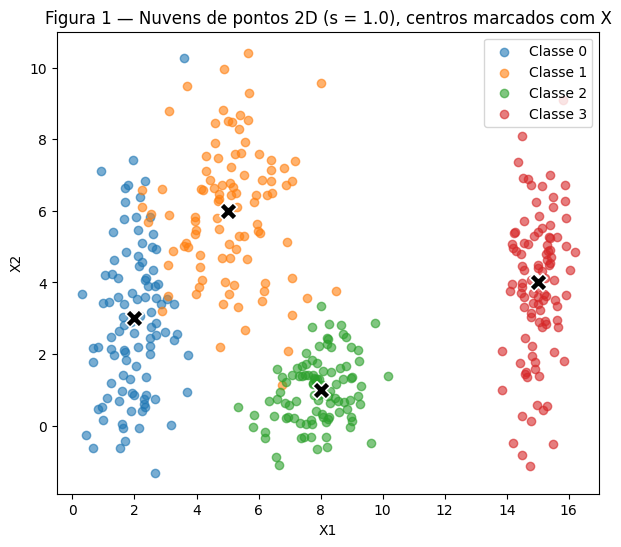

In [ ]:
means = {
    0: np.array([2.0, 3.0]),
    1: np.array([5.0, 6.0]),
    2: np.array([8.0, 1.0]),
    3: np.array([15.0, 4.0]),
}
stds = {
    0: np.array([0.8, 2.5]),
    1: np.array([1.2, 1.9]),
    2: np.array([0.9, 0.9]),
    3: np.array([0.5, 2.0]),
}
N_PER_CLASS = 100
N_CLASSES = 4


def make_clouds(rng, means, stds, s=1.0, n_per_class=N_PER_CLASS):
    points, labels = [], []
    for k in sorted(means):
        pts = rng.normal(loc=means[k], scale=stds[k] * s, size=(n_per_class, 2))
        points.append(pts)
        labels.append(np.full(n_per_class, k))
    return np.vstack(points), np.concatenate(labels)


X1, y1 = make_clouds(rng, means, stds, s=1.0)

fig, ax = plt.subplots(figsize=(7, 6))
for k in sorted(means):
    mask = y1 == k
    ax.scatter(X1[mask, 0], X1[mask, 1], alpha=0.6, label=f"Classe {k}")
    ax.scatter(*means[k], marker="X", s=160, c="black", edgecolors="white", linewidths=1.2, zorder=5)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("Figura 1 — Nuvens de pontos 2D (s = 1.0), centros marcados com X")
ax.legend()
plt.show()

**Figura 1** mostra as 400 amostras (100 por classe) e o centro (média) de cada nuvem
marcado com um "X" preto.

### Parte B — Mais ou menos espalhado

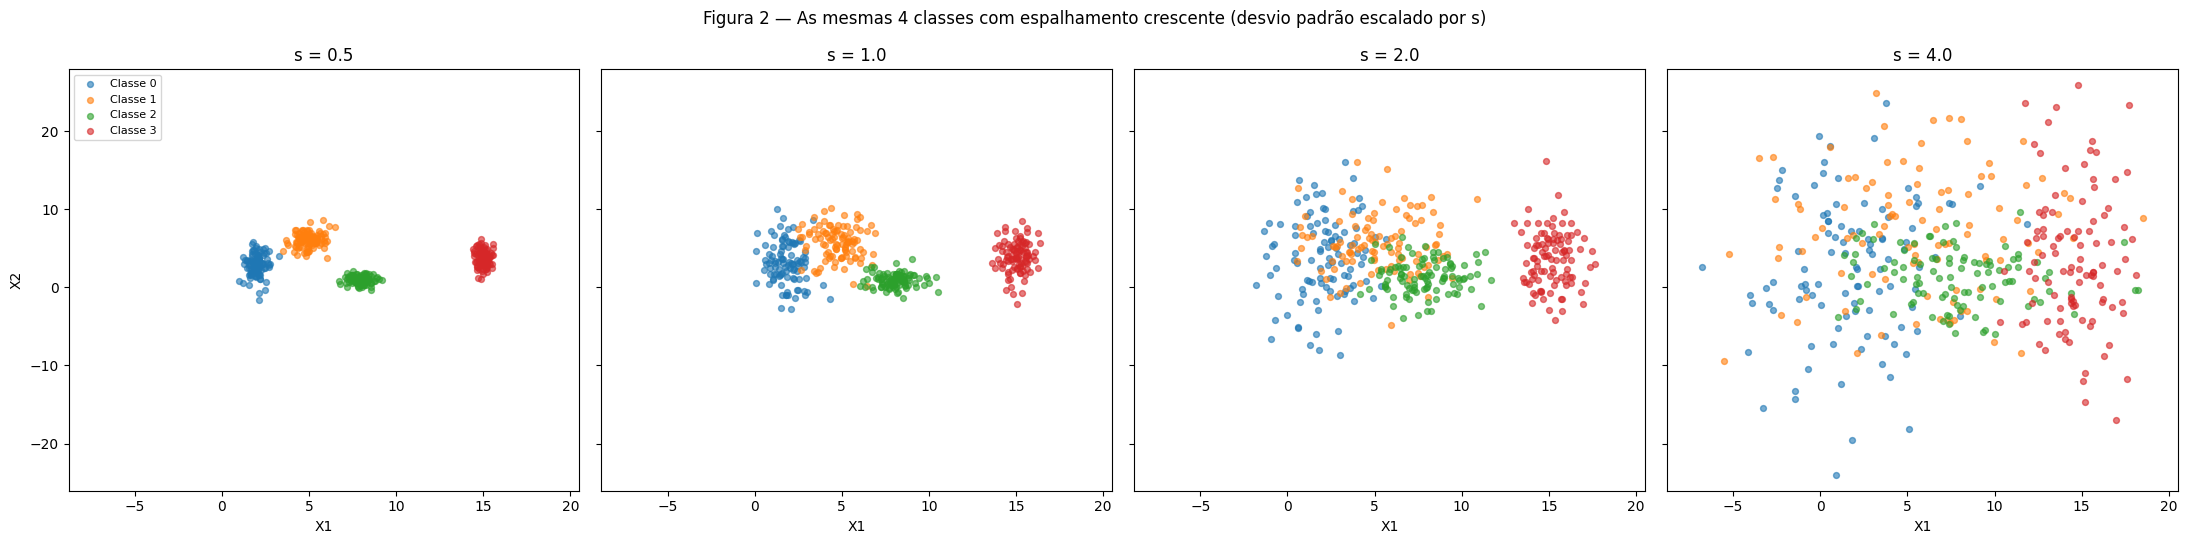

In [ ]:
scale_factors = [0.5, 1.0, 2.0, 4.0]

datasets_by_s = {s: make_clouds(rng, means, stds, s=s) for s in scale_factors}


all_x = np.concatenate([datasets_by_s[s][0][:, 0] for s in scale_factors])
all_y = np.concatenate([datasets_by_s[s][0][:, 1] for s in scale_factors])
pad = 2.0
xlim = (all_x.min() - pad, all_x.max() + pad)
ylim = (all_y.min() - pad, all_y.max() + pad)

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharex=True, sharey=True)
for ax, s in zip(axes, scale_factors):
    Xs, ys = datasets_by_s[s]
    for k in sorted(means):
        mask = ys == k
        ax.scatter(Xs[mask, 0], Xs[mask, 1], alpha=0.6, s=18, label=f"Classe {k}")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel("X1")
    ax.set_title(f"s = {s}")
axes[0].set_ylabel("X2")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Figura 2 — As mesmas 4 classes com espalhamento crescente (desvio padrão escalado por s)")
plt.tight_layout()
plt.show()

In [4]:
def sigma_bar(std_xy):
    return std_xy.mean()


pairs = list(combinations(sorted(means), 2))
rows = []
for i, j in pairs:
    dist = np.linalg.norm(means[i] - means[j])
    denom = sigma_bar(stds[i]) + sigma_bar(stds[j])
    r_ij = dist / denom
    rows.append({"par": f"({i}, {j})", "||mu_i - mu_j||": dist, "sigma_bar_i + sigma_bar_j": denom, "r_ij (s=1)": r_ij})

r_table = pd.DataFrame(rows).sort_values("r_ij (s=1)").reset_index(drop=True)
r_table

,par,||mu_i - mu_j||,sigma_bar_i + sigma_bar_j,r_ij (s=1)
0,"(0, 1)",4.242641,3.20,1.325825
1,"(1, 2)",5.830952,2.45,2.379980
2,"(0, 2)",6.324555,2.55,2.480218
3,"(2, 3)",7.615773,2.15,3.542220
4,"(1, 3)",10.198039,2.80,3.642157
5,"(0, 3)",13.038405,2.90,4.496002


In [ ]:
smallest_row = r_table.iloc[0]
smallest_pair = smallest_row["par"]
r_smallest_s1 = smallest_row["r_ij (s=1)"]
r_smallest_s2 = r_smallest_s1 / 2.0  

print(f"Menor razão de separação em s=1.0: par {smallest_pair}, r_ij = {r_smallest_s1:.4f}")
print(f"r_ij previsto para o mesmo par em s=2.0 (r_ij(s) = r_ij(1)/s): {r_smallest_s2:.4f}")

Menor razão de separação em s=1.0: par (0, 1), r_ij = 1.3258
r_ij previsto para o mesmo par em s=2.0 (r_ij(s) = r_ij(1)/s): 0.6629


A classe 0 e a classe 1 têm o menor `r_ij` em `s = 1.0` — são as médias mais próximas em
relação ao espalhamento combinado das duas nuvens, e por isso são as mais difíceis de
separar. Como as médias não mudam com `s` e `sigma_bar` escala linearmente com `s`, `r_ij`
escala com `1/s`: em `s = 2.0`, o mesmo par teria metade do `r_ij` de `s = 1.0` — ainda mais
sobreposição, sem precisar gerar nada de novo.

s =  0.5: taxa de mistura = 0.000
s =  1.0: taxa de mistura = 0.068
s =  2.0: taxa de mistura = 0.225
s =  4.0: taxa de mistura = 0.417


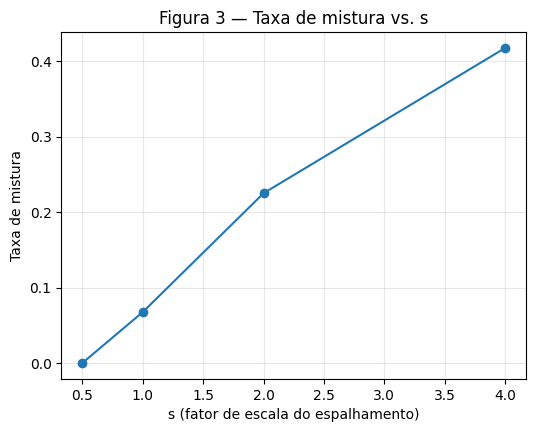

In [ ]:
def mixing_rate(points, labels, means):
    mu = np.array([means[k] for k in sorted(means)]) 
    dists = np.linalg.norm(points[:, None, :] - mu[None, :, :], axis=2)  
    nearest = np.argmin(dists, axis=1)
    return np.mean(nearest != labels)


mixing_rates = {s: mixing_rate(*datasets_by_s[s], means) for s in scale_factors}
for s in scale_factors:
    print(f"s = {s:>4}: taxa de mistura = {mixing_rates[s]:.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(scale_factors, [mixing_rates[s] for s in scale_factors], marker="o")
ax.set_xlabel("s (fator de escala do espalhamento)")
ax.set_ylabel("Taxa de mistura")
ax.set_title("Figura 3 — Taxa de mistura vs. s")
ax.grid(alpha=0.3)
plt.show()

### Parte C — Análise

**1. Sobreposição em s = 1 — uma única fronteira linear separaria todas as classes?**
Olhando a Figura 1: as classes 0 e 1 se sobrepõem bastante (menor `r_ij`, calculado acima),
enquanto a classe 3 fica isolada no extremo direito do eixo X1 e a classe 2 fica razoavelmente
separada das demais. Uma única reta não separa as quatro classes, ela consegue, no máximo,
isolar uma classe de todas as outras de um lado só. Um **conjunto** de retas (fronteiras
lineares por partes, como as que um MLP com poucas camadas aprende) já dá conta: uma reta
isola a classe 3 à direita, outra isola a classe 2 abaixo, e uma terceira, mais "suave" (com
erro residual), tenta separar 0 de 1 na região de maior sobreposição.

**2. Esboço — Figura 1 com as fronteiras.**

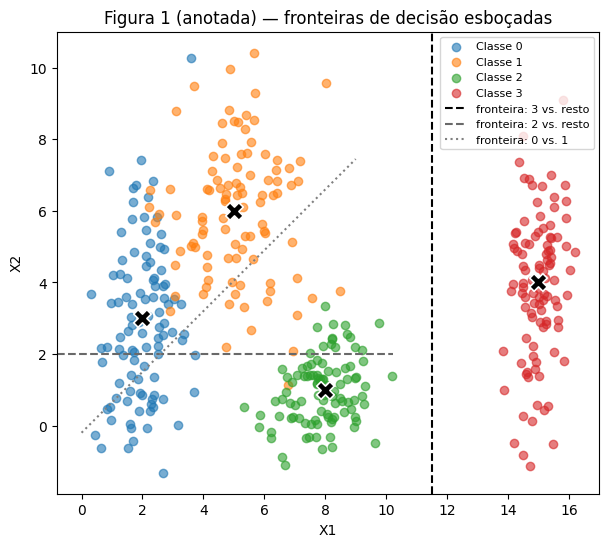

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for k in sorted(means):
    mask = y1 == k
    ax.scatter(X1[mask, 0], X1[mask, 1], alpha=0.6, label=f"Classe {k}")
    ax.scatter(*means[k], marker="X", s=160, c="black", edgecolors="white", linewidths=1.2, zorder=5)


ax.axvline(11.5, color="black", linestyle="--", linewidth=1.5, label="fronteira: 3 vs. resto")
ax.axhline(2.0, xmin=0.0, xmax=0.62, color="dimgray", linestyle="--", linewidth=1.5, label="fronteira: 2 vs. resto")
x_diag = np.linspace(0, 9, 50)
ax.plot(x_diag, 0.85 * x_diag - 0.2, color="gray", linestyle=":", linewidth=1.5, label="fronteira: 0 vs. 1")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("Figura 1 (anotada) — fronteiras de decisão esboçadas")
ax.legend(fontsize=8)
plt.show()

As fronteiras acima são só uma aproximação visual do que uma rede aprenderia: uma reta
vertical isola a classe 3 (bem afastada no eixo X1), uma reta horizontal isola a maior parte
da classe 2, e uma diagonal tenta separar 0 de 1 na região onde elas mais se sobrepõem, sem
conseguir uma separação perfeita, porque ali os pontos realmente se misturam.

**3. Relação com a Parte B.** Conforme `s` aumenta, os `r_ij` diminuem (escalam com `1/s`) e
a taxa de mistura sobe (Figura 3): as nuvens racham as fronteiras "limpas" que existiam em
`s = 0.5`, e a região onde qualquer classificador, linear ou não, é forçado a errar cresce
junto com o espalhamento. Em outras palavras, a rede não erra por falta de capacidade, mas
porque, na região de sobreposição, pontos de classes diferentes ocupam literalmente o mesmo
espaço, nenhuma fronteira, por mais flexível que seja, resolve isso.

## Exercício 2 — Não Linearidade em Dimensões Maiores

### Parte A — Dataset I: Gaussianas deslocadas

In [ ]:
mu_A = np.array([0.0, 0.0, 0.0, 0.0, 0.0])
Sigma_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0],
])

mu_B = np.array([1.5, 1.5, 1.5, 1.5, 1.5])
Sigma_B = np.array([
    [1.5, -0.7, 0.2, 0.0, 0.0],
    [-0.7, 1.5, 0.4, 0.0, 0.0],
    [0.2, 0.4, 1.5, 0.6, 0.0],
    [0.0, 0.0, 0.6, 1.5, 0.3],
    [0.0, 0.0, 0.0, 0.3, 1.5],
])

N_HD = 500
class_A = rng.multivariate_normal(mu_A, Sigma_A, size=N_HD)
class_B = rng.multivariate_normal(mu_B, Sigma_B, size=N_HD)

X_ds1 = np.vstack([class_A, class_B])
y_ds1 = np.array([0] * N_HD + [1] * N_HD)  

print("Formato do Dataset I:", X_ds1.shape)

Formato do Dataset I: (1000, 5)


### Parte B — Dataset II: cascas concêntricas

In [ ]:
def sample_shell(rng, n, dim, radius_mean, radius_std):
    directions = rng.standard_normal((n, dim))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    radii = rng.normal(radius_mean, radius_std, size=n)
    return directions * radii[:, None], radii


DIM = 5
class_C, radii_C = sample_shell(rng, N_HD, DIM, radius_mean=2.0, radius_std=0.4)
class_D, radii_D = sample_shell(rng, N_HD, DIM, radius_mean=5.0, radius_std=0.4)

X_ds2 = np.vstack([class_C, class_D])
y_ds2 = np.array([0] * N_HD + [1] * N_HD) 

print("Formato do Dataset II:", X_ds2.shape)

Formato do Dataset II: (1000, 5)


### Parte C — Visualizar e comparar

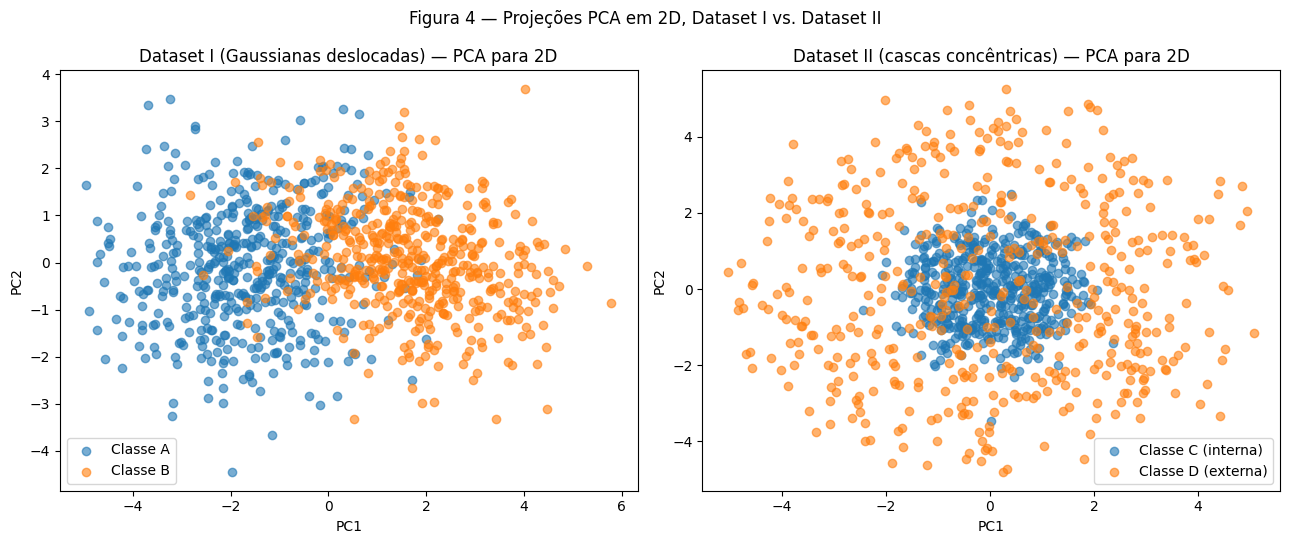

Variância explicada (PC1 + PC2) — Dataset I:  0.673
Variância explicada (PC1 + PC2) — Dataset II: 0.431
Distância entre centros das classes — Dataset I:  3.332
Distância entre centros das classes — Dataset II: 0.235


In [10]:
from sklearn.decomposition import PCA

pca1 = PCA(n_components=2)
X_ds1_pca = pca1.fit_transform(X_ds1)

pca2 = PCA(n_components=2)
X_ds2_pca = pca2.fit_transform(X_ds2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for k, name in [(0, "Classe A"), (1, "Classe B")]:
    mask = y_ds1 == k
    axes[0].scatter(X_ds1_pca[mask, 0], X_ds1_pca[mask, 1], alpha=0.6, label=name)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Dataset I (Gaussianas deslocadas) — PCA para 2D")
axes[0].legend()

for k, name in [(0, "Classe C (interna)"), (1, "Classe D (externa)")]:
    mask = y_ds2 == k
    axes[1].scatter(X_ds2_pca[mask, 0], X_ds2_pca[mask, 1], alpha=0.6, label=name)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Dataset II (cascas concêntricas) — PCA para 2D")
axes[1].legend()

fig.suptitle("Figura 4 — Projeções PCA em 2D, Dataset I vs. Dataset II")
plt.tight_layout()
plt.show()

ev1 = pca1.explained_variance_ratio_.sum()
ev2 = pca2.explained_variance_ratio_.sum()
print(f"Variância explicada (PC1 + PC2) — Dataset I:  {ev1:.3f}")
print(f"Variância explicada (PC1 + PC2) — Dataset II: {ev2:.3f}")

dist_centers_1 = np.linalg.norm(class_A.mean(axis=0) - class_B.mean(axis=0))
dist_centers_2 = np.linalg.norm(class_C.mean(axis=0) - class_D.mean(axis=0))
print(f"Distância entre centros das classes — Dataset I:  {dist_centers_1:.3f}")
print(f"Distância entre centros das classes — Dataset II: {dist_centers_2:.3f}")

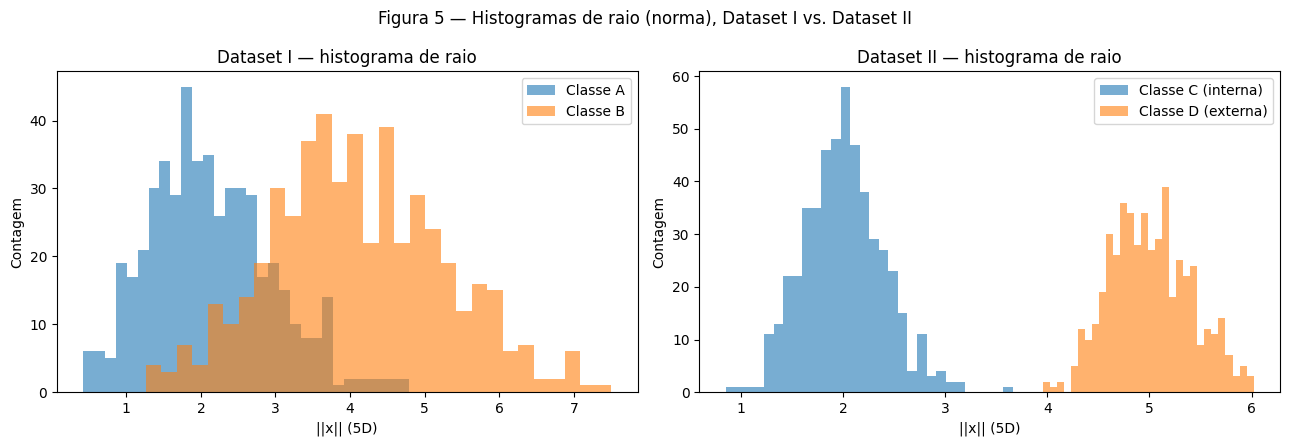

In [11]:
radii_ds1_A = np.linalg.norm(class_A, axis=1)
radii_ds1_B = np.linalg.norm(class_B, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(radii_ds1_A, bins=30, alpha=0.6, label="Classe A")
axes[0].hist(radii_ds1_B, bins=30, alpha=0.6, label="Classe B")
axes[0].set_xlabel("||x|| (5D)")
axes[0].set_ylabel("Contagem")
axes[0].set_title("Dataset I — histograma de raio")
axes[0].legend()

axes[1].hist(radii_C, bins=30, alpha=0.6, label="Classe C (interna)")
axes[1].hist(radii_D, bins=30, alpha=0.6, label="Classe D (externa)")
axes[1].set_xlabel("||x|| (5D)")
axes[1].set_ylabel("Contagem")
axes[1].set_title("Dataset II — histograma de raio")
axes[1].legend()

fig.suptitle("Figura 5 — Histogramas de raio (norma), Dataset I vs. Dataset II")
plt.tight_layout()
plt.show()

In [ ]:
threshold = (2.0**2 + 5.0**2) / 2  
sq_norms = np.sum(X_ds2 ** 2, axis=1)
pred = (sq_norms > threshold).astype(int)
accuracy = np.mean(pred == y_ds2)

print(f"Limiar de ||x||²: {threshold:.2f}")
print(f"Acurácia da regra  'prever Classe D se ||x||² > {threshold:.1f}'  no Dataset II: {accuracy:.3f}")

Limiar de ||x||²: 14.50
Acurácia da regra  'prever Classe D se ||x||² > 14.5'  no Dataset II: 1.000


### Parte D — Análise

**Centros coincidentes + raios separados.** O centro (média) das classes C e D fica muito
próximo da origem para as duas (`distância entre centros ≈ ` valor impresso acima, bem menor
que a distância entre A e B), porque a direção de cada ponto é sorteada uniformemente na
esfera, então, em média, os vetores se cancelam. Ao mesmo tempo, os histogramas de raio
(Figura 5, painel direito) são bem separados: C fica concentrada perto de `||x|| ≈ 2` e D
perto de `||x|| ≈ 5`, quase sem sobreposição. Isso mostra que a classe está codificada na
**distância à origem**, não na posição média — e centro coincidente é exatamente o cenário em
que nenhum hiperplano consegue separar as classes, porque um hiperplano é definido por um
vetor normal a partir de uma origem deslocada, e aqui as duas classes têm a mesma "origem"
em todas as direções.

**Por que nenhuma fronteira linear resolve o Dataset II.** Um classificador linear separa o
espaço em dois semiespaços através de um único hiperplano. Como os pontos de C e D estão
distribuídos em **todas** as direções ao redor da origem (só variam em raio), qualquer
hiperplano que você desenhar corta as duas cascas esféricas, de um lado e do outro dele
sempre existirão pontos de ambas as classes, em qualquer direção. Coletar mais dados não
muda esse fato geométrico: a estrutura permanece radialmente simétrica não importa quantos
pontos você amostre.

**A projeção PCA ruim não prova inseparabilidade.** O painel direito da Figura 4 mostra as
classes C e D bem misturadas em 2D, mas isso é uma limitação da **projeção linear** (PCA
usa apenas combinações lineares das 5 dimensões), não do problema original. Uma projeção
linear de uma casca esférica em 5D pode perder justamente a informação de raio que separa as
classes, porque duas direções ortogonais escolhidas por variância não preservam a norma dos
vetores. Uma função **não linear** simples resolve o problema: usando
`||x||² = Σᵢ xᵢ²` (a soma dos quadrados das coordenadas, que recupera a informação de raio
que a PCA "achatou"), a regra `||x||² > 14.5` classifica corretamente a quase totalidade dos
pontos do Dataset II (acurácia calculada acima),evidência direta de que o problema é
perfeitamente separável, só que não por uma fronteira linear.

## Exercício 3 — Pré-processamento de Dados Reais

### Parte A — Conhecendo os dados

In [13]:
df = pd.read_csv("SpaceshipTitanic/train.csv")
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [14]:
target_balance = df["Transported"].value_counts(normalize=True).sort_index()
print("Transported — balanço das classes:")
print(target_balance)

Transported — balanço das classes:
Transported
False    0.496376
True     0.503624
Name: proportion, dtype: float64


`Transported` indica se o passageiro foi transportado para outra dimensão no acidente da
Spaceship Titanic — é o alvo binário do problema. A base está bem balanceada: cerca de
**50.4% True / 49.6% False**.

**Features numéricas:** `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`.

**Features categóricas:** `HomePlanet`, `CryoSleep`, `Destination`, `VIP`, `Cabin`, `Name`
(estas duas últimas serão descartadas — não carregam sinal generalizável para uma rede).

In [15]:
missing = pd.DataFrame({
    "quantidade_faltante": df.isnull().sum(),
    "percentual_faltante": (df.isnull().mean() * 100).round(2),
})
missing = missing[missing["quantidade_faltante"] > 0].sort_values("quantidade_faltante", ascending=False)
missing

,quantidade_faltante,percentual_faltante
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
FoodCourt,183,2.11
Spa,183,2.11
Destination,182,2.09


In [16]:
spend_features = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
spend_stats = df[spend_features].agg(["mean", "median", "max"]).T
spend_stats

,mean,median,max
RoomService,224.687617,0.0,14327.0
FoodCourt,458.077203,0.0,29813.0
ShoppingMall,173.729169,0.0,23492.0
Spa,311.138778,0.0,22408.0
VRDeck,304.854791,0.0,24133.0


Em todas as 5 colunas de gastos, a **média é muito maior que a mediana** (ex.: `FoodCourt`
tem mediana 0 mas média bem acima disso), e o **máximo** é uma ordem de grandeza maior que a
média. Isso é a assinatura clássica de uma distribuição **assimétrica à direita** (skewed):
a maioria dos passageiros gasta pouco ou nada, e uma minoria gasta muito, daí a necessidade
do `log(1+x)` mais adiante, antes de padronizar.

### Parte B — Divida antes de transformar

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["Transported"], random_state=42
)

print("Formato do treino:", train_df.shape, "| Formato do teste:", test_df.shape)
print("Balanço do treino:\n", train_df["Transported"].value_counts(normalize=True).sort_index())
print("Balanço do teste:\n", test_df["Transported"].value_counts(normalize=True).sort_index())

Formato do treino: (6954, 14) | Formato do teste: (1739, 14)
Balanço do treino:
 Transported
False    0.496405
True     0.503595
Name: proportion, dtype: float64
Balanço do teste:
 Transported
False    0.496262
True     0.503738
Name: proportion, dtype: float64


O split acontece **antes** de qualquer imputação, codificação ou escala. Se a mediana, a
moda ou os parâmetros do `StandardScaler`/`MinMaxScaler` fossem calculados no dataset
inteiro (treino + teste), o teste "vazaria" informação para o treino — a rede seria avaliada
com estatísticas que ela não teria disponíveis num cenário real, de produção, onde o teste
não existe ainda no momento do treino. Por isso todo `fit` das próximas etapas acontece
**só** em `train_df`, e `test_df` apenas recebe `transform`.

### Parte C — Pré-processamento

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_features = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
cat_features = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
drop_cols = ["PassengerId", "Name", "Cabin"]

train_p = train_df.drop(columns=drop_cols).copy()
test_p = test_df.drop(columns=drop_cols).copy()

num_imputer = SimpleImputer(strategy="median")
train_p[num_features] = num_imputer.fit_transform(train_p[num_features])
test_p[num_features] = num_imputer.transform(test_p[num_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
train_p[cat_features] = cat_imputer.fit_transform(train_p[cat_features])
test_p[cat_features] = cat_imputer.transform(test_p[cat_features])

print("NaNs restantes após imputação — treino:", train_p[num_features + cat_features].isnull().sum().sum())
print("NaNs restantes após imputação — teste: ", test_p[num_features + cat_features].isnull().sum().sum())

NaNs restantes após imputação — treino: 0
NaNs restantes após imputação — teste:  0


In [ ]:
train_p["TotalSpend"] = train_p[spend_features].sum(axis=1)
test_p["TotalSpend"] = test_p[spend_features].sum(axis=1)

log_features = spend_features + ["TotalSpend"]
foodcourt_before = train_p["FoodCourt"].copy() 

for col in log_features:
    train_p[col] = np.log1p(train_p[col])
    test_p[col] = np.log1p(test_p[col])

train_p[log_features].describe().T[["mean", "50%", "max"]]

,mean,50%,max
RoomService,1.754547,0.00000,9.569971
FoodCourt,1.882516,0.00000,10.302733
ShoppingMall,1.577178,0.00000,9.413608
Spa,1.810592,0.00000,10.017218
VRDeck,1.745920,0.00000,9.920197
TotalSpend,4.228987,6.57368,10.490941


`log(1+x)` comprime a cauda longa das colunas de gasto (poucos passageiros gastando muito)
sem quebrar em zero (a maioria dos passageiros tem gasto 0, e `log(1+0) = 0`). O resultado é
uma distribuição bem mais simétrica, que a padronização seguinte consegue centrar em 0 sem
deixar alguns poucos outliers dominarem a escala, exatamente o que a `tanh` precisa para não
saturar logo na entrada.

In [ ]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_cat = encoder.fit_transform(train_p[cat_features])
test_cat = encoder.transform(test_p[cat_features])
cat_columns = encoder.get_feature_names_out(cat_features)

print("Colunas one-hot:", list(cat_columns))

Colunas one-hot: ['HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'CryoSleep_False', 'CryoSleep_True', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP_False', 'VIP_True']


`handle_unknown="ignore"` cobre o caso de uma categoria aparecer no teste mas não no treino:
em vez de dar erro, o encoder simplesmente gera um vetor de zeros para aquela linha em todas
as colunas daquela feature original, a linha não é descartada, só fica sem nenhuma
categoria "ligada".

In [ ]:
scale_features = num_features + ["TotalSpend"]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_p[scale_features])
test_scaled = scaler.transform(test_p[scale_features])

X_train = np.hstack([train_scaled, train_cat])
X_test = np.hstack([test_scaled, test_cat])
y_train = train_df["Transported"].to_numpy()
y_test = test_df["Transported"].to_numpy()

print("Formato de X_train:", X_train.shape, "| Formato de X_test:", X_test.shape)

Formato de X_train: (6954, 17) | Formato de X_test: (1739, 17)


Escolhi **standardização** (média 0, desvio padrão 1) em vez de normalizar para `[-1, 1]`:
depois do `log1p`, as colunas de gasto ainda têm alguns outliers residuais, e a
padronização não os esmaga contra os limites do intervalo do jeito que um `MinMaxScaler`
faria (onde um único outlier definiria a escala inteira). Continua sendo uma ótima entrada
para `tanh`, média 0 mantém a maior parte dos valores na região linear (não saturada) da
função, perto de onde o gradiente é maior.

### Parte D — Verificar e visualizar

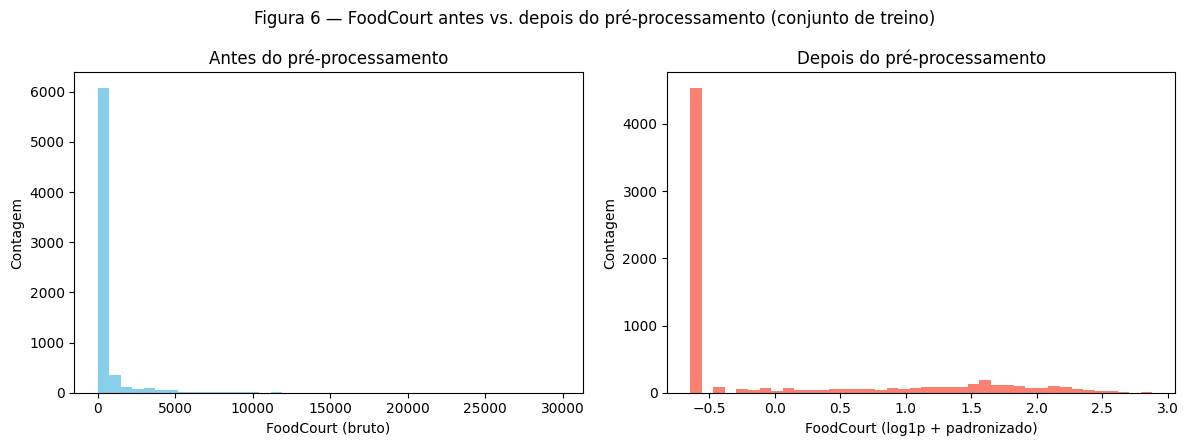

In [ ]:
foodcourt_after = train_p["FoodCourt"]
foodcourt_after_scaled = train_scaled[:, num_features.index("FoodCourt")]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(foodcourt_before, bins=40, color="skyblue")
axes[0].set_xlabel("FoodCourt (bruto)")
axes[0].set_ylabel("Contagem")
axes[0].set_title("Antes do pré-processamento")

axes[1].hist(foodcourt_after_scaled, bins=40, color="salmon")
axes[1].set_xlabel("FoodCourt (log1p + padronizado)")
axes[1].set_ylabel("Contagem")
axes[1].set_title("Depois do pré-processamento")

fig.suptitle("Figura 6 — FoodCourt antes vs. depois do pré-processamento (conjunto de treino)")
plt.tight_layout()
plt.show()

In [23]:
n_nan_train = np.isnan(X_train).sum()
n_nan_test = np.isnan(X_test).sum()
final_shape = X_train.shape
train_min, train_max = X_train.min(), X_train.max()
test_min, test_max = X_test.min(), X_test.max()

print(f"NaNs restantes — treino: {n_nan_train}, teste: {n_nan_test}")
print(f"Formato final da matriz de features de treino: {final_shape}")
print(f"Intervalo do treino após a escala: [{train_min:.3f}, {train_max:.3f}]")
print(f"Intervalo do teste após a escala:  [{test_min:.3f}, {test_max:.3f}]")

NaNs restantes — treino: 0, teste: 0
Formato final da matriz de features de treino: (6954, 17)
Intervalo do treino após a escala: [-1.996, 3.508]
Intervalo do teste após a escala:  [-1.996, 3.369]


Sem nenhum `NaN` restante em treino ou teste. A padronização não garante limites exatos em
    `[-1, 1]` (ela centra a média em 0 e o desvio padrão em 1, mas não recorta o intervalo) por
isso o teste, em particular, pode extrapolar um pouco além do que o treino viu, o que é
esperado e aceitável: a maior parte da massa dos dados ainda cai perto de zero, região
central e não saturada da `tanh`.

**Reflexão.** Entre as decisões de pré-processamento, a que mais deve afetar o treino é o
**`log(1+x)` nas colunas de gasto**: sem ele, a padronização sozinha deixaria a distribuição
extremamente assimétrica (média puxada pelos poucos gastos altos), e a maioria dos valores
ficaria espremida perto de zero enquanto uns poucos outliers dominariam a escala do gradiente, exatamente o tipo de situação que faz a `tanh` saturar cedo para a maior parte dos
exemplos. O `log1p` "linear iza" essa distribuição antes de ela chegar à rede, o que deve
acelerar a convergência bem mais do que, por exemplo, a escolha entre imputar por mediana ou
por média nos poucos valores faltantes.

## Resumo dos resultados

In [24]:
summary = pd.DataFrame([
    {"#": 1, "Item": "Taxa de mistura em s = 0.5", "Value": f"{mixing_rates[0.5]:.3f}"},
    {"#": 2, "Item": "Taxa de mistura em s = 1.0", "Value": f"{mixing_rates[1.0]:.3f}"},
    {"#": 3, "Item": "Taxa de mistura em s = 2.0", "Value": f"{mixing_rates[2.0]:.3f}"},
    {"#": 4, "Item": "Taxa de mistura em s = 4.0", "Value": f"{mixing_rates[4.0]:.3f}"},
    {"#": 5, "Item": "Menor r_ij em s = 1.0 (par)", "Value": f"{r_smallest_s1:.4f} (par {smallest_pair})"},
    {"#": 6, "Item": "Distância entre centros — Dataset I", "Value": f"{dist_centers_1:.3f}"},
    {"#": 7, "Item": "Distância entre centros — Dataset II", "Value": f"{dist_centers_2:.3f}"},
    {"#": 8, "Item": "Variância explicada PC1+PC2 — Dataset I", "Value": f"{ev1:.3f}"},
    {"#": 9, "Item": "Variância explicada PC1+PC2 — Dataset II", "Value": f"{ev2:.3f}"},
    {"#": 10, "Item": "Proporção da classe positiva em Transported", "Value": f"{target_balance[True]:.3f}"},
    {"#": 11, "Item": "Média / mediana de FoodCourt no treino (antes de transformar)",
     "Value": f"média={foodcourt_before.mean():.2f}, mediana={foodcourt_before.median():.2f}"},
    {"#": 12, "Item": "Formato final da matriz de features de treino", "Value": str(final_shape)},
    {"#": 13, "Item": "Mínimo / máximo de treino/teste após a escala",
     "Value": f"treino=[{train_min:.3f}, {train_max:.3f}], teste=[{test_min:.3f}, {test_max:.3f}]"},
])
summary

,#,Item,Value
0,1,Taxa de mistura em s = 0.5,0.000
1,2,Taxa de mistura em s = 1.0,0.068
2,3,Taxa de mistura em s = 2.0,0.225
3,4,Taxa de mistura em s = 4.0,0.417
4,5,Menor r_ij em s = 1.0 (par),"1.3258 (par (0, 1))"
5,6,Distância entre centros — Dataset I,3.332
6,7,Distância entre centros — Dataset II,0.235
7,8,Variância explicada PC1+PC2 — Dataset I,0.673
8,9,Variância explicada PC1+PC2 — Dataset II,0.431
9,10,Proporção da classe positiva em Transported,0.504
